In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [84]:
df = pd.read_csv("student_dataset_10000_rows.csv")

In [5]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [6]:
df.tail()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed
9999,2,70,6,11,16,52,78.96,Placed


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 8


In [8]:
print("Columns in the dataset:")

for column in df.columns:
    print("-", column)

Columns in the dataset:
- study_hours
- attendance
- sleep_hours
- internet_usage
- assignments_completed
- previous_score
- exam_score
- placement_status


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [10]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
study_hours,0,0.0
attendance,0,0.0
sleep_hours,0,0.0
internet_usage,0,0.0
assignments_completed,0,0.0
previous_score,0,0.0
exam_score,0,0.0
placement_status,0,0.0


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [14]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (10000, 8)


In [15]:
df.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status          object
dtype: object

In [16]:
print(df["placement_status"].value_counts())

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64


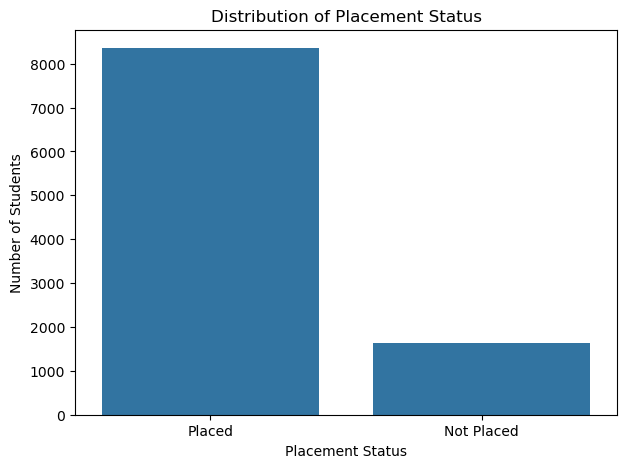

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="placement_status"
)

plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

In [18]:
df["performance"] = np.where(
    df["exam_score"] >= 40,
    "Pass",
    "Fail"
)

df[["exam_score", "performance"]].head(10)

,exam_score,performance
0,100.00,Pass
1,100.00,Pass
2,100.00,Pass
3,90.17,Pass
4,78.82,Pass
5,72.33,Pass
6,98.12,Pass
7,100.00,Pass
8,96.81,Pass
9,100.00,Pass


In [19]:
print(df["performance"].value_counts())

performance
Pass    9955
Fail      45
Name: count, dtype: int64


In [20]:
performance_percentage = (
    df["performance"].value_counts(normalize=True) * 100
)

print(performance_percentage)

performance
Pass    99.55
Fail     0.45
Name: proportion, dtype: float64


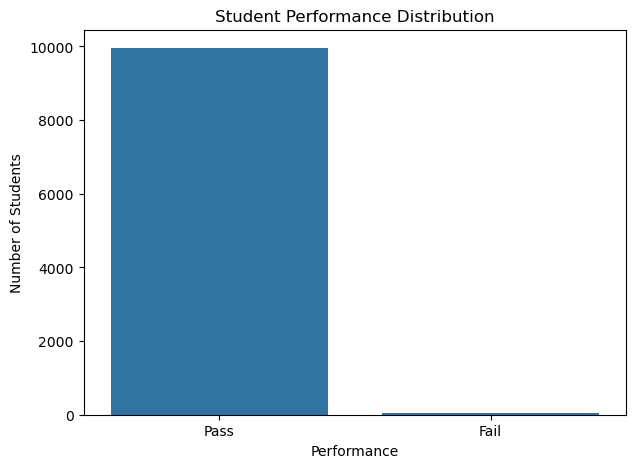

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="performance"
)

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

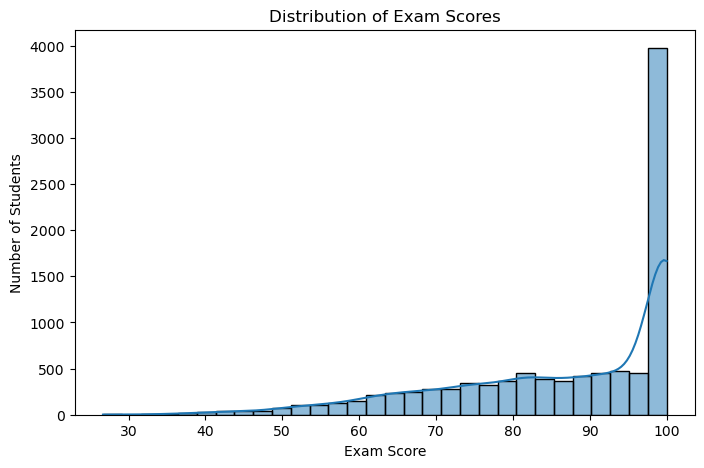

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["exam_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

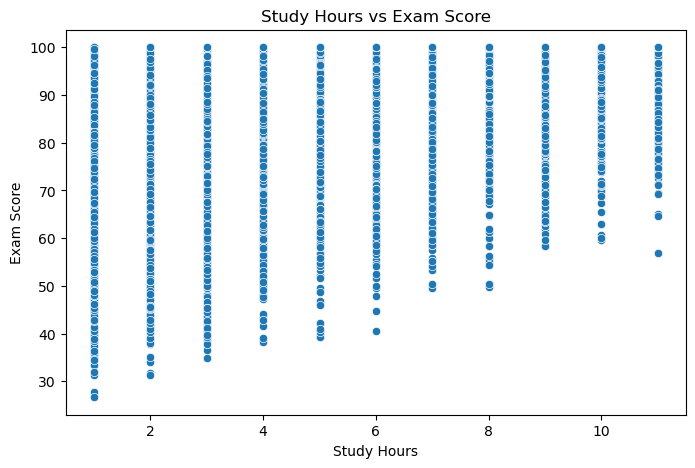

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="study_hours",
    y="exam_score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.show()

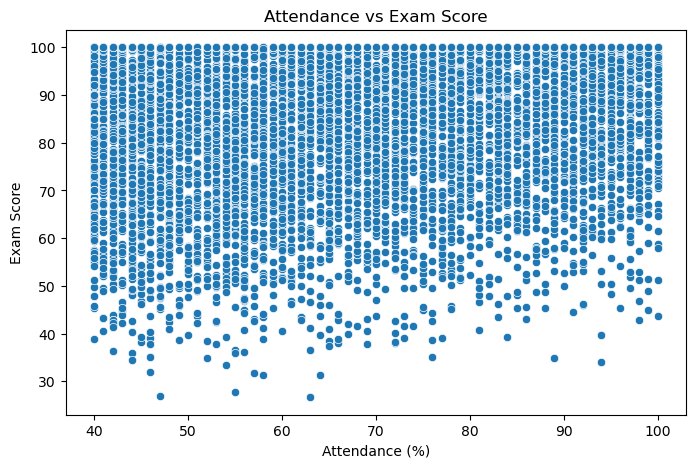

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance",
    y="exam_score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

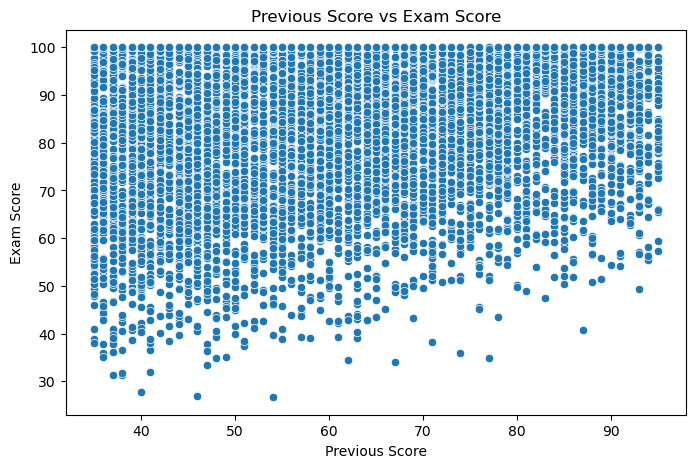

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="previous_score",
    y="exam_score"
)

plt.title("Previous Score vs Exam Score")
plt.xlabel("Previous Score")
plt.ylabel("Exam Score")

plt.show()

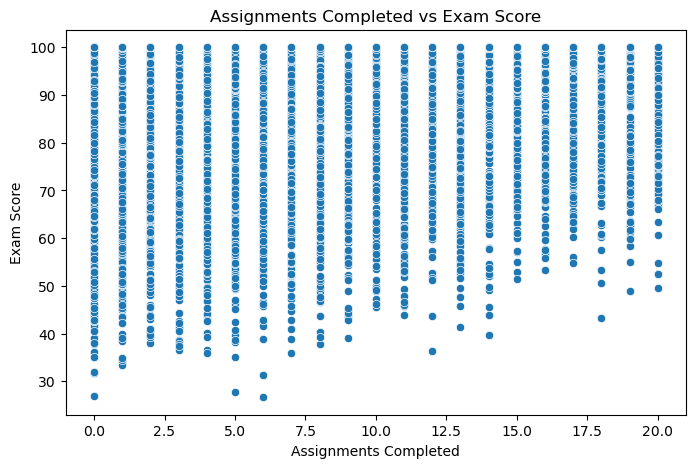

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="assignments_completed",
    y="exam_score"
)

plt.title("Assignments Completed vs Exam Score")
plt.xlabel("Assignments Completed")
plt.ylabel("Exam Score")

plt.show()

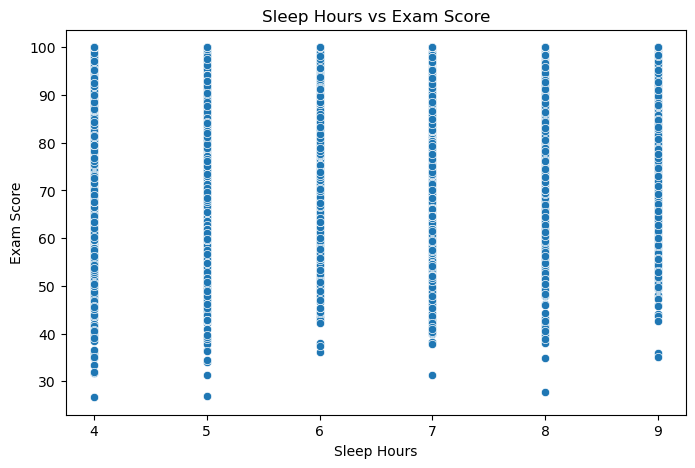

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sleep_hours",
    y="exam_score"
)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")

plt.show()

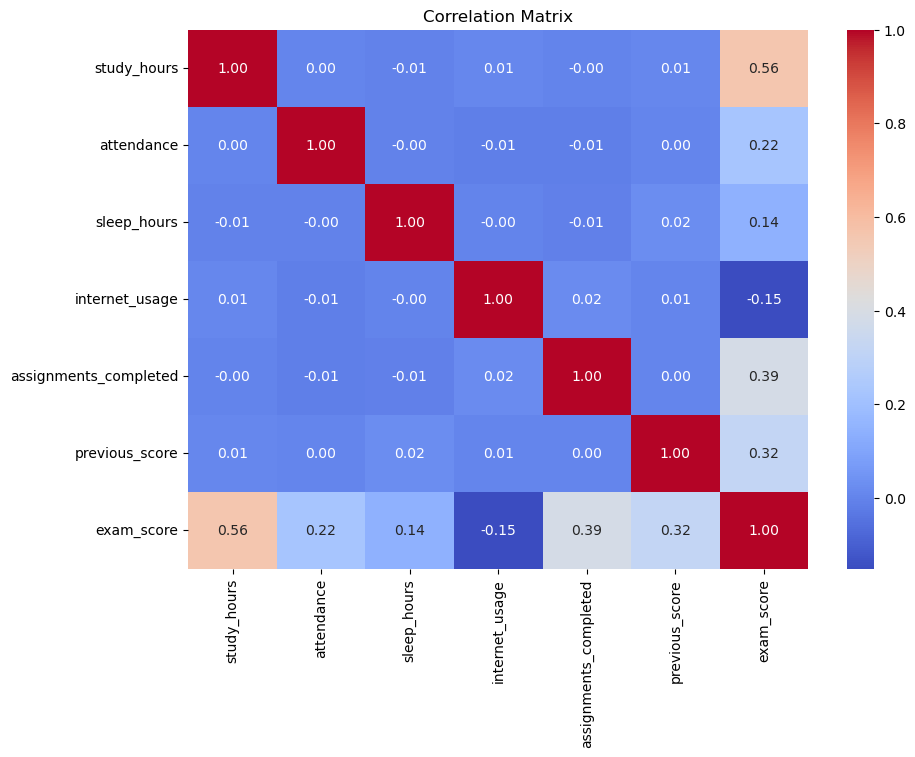

In [28]:
numeric_columns = [
    "study_hours",
    "attendance",
    "sleep_hours",
    "internet_usage",
    "assignments_completed",
    "previous_score",
    "exam_score"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

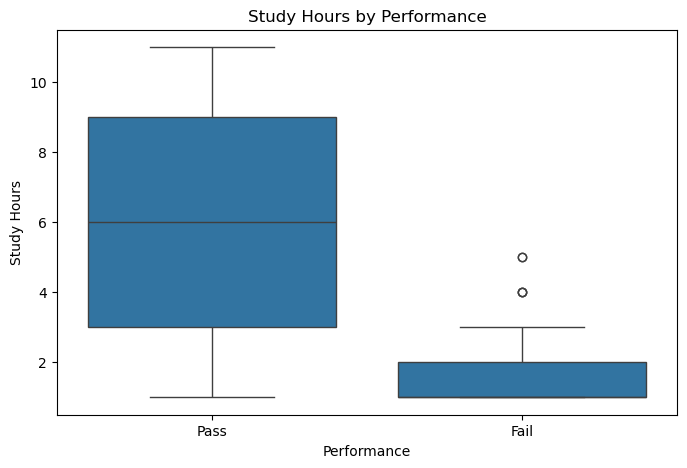

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="performance",
    y="study_hours"
)

plt.title("Study Hours by Performance")
plt.xlabel("Performance")
plt.ylabel("Study Hours")

plt.show()

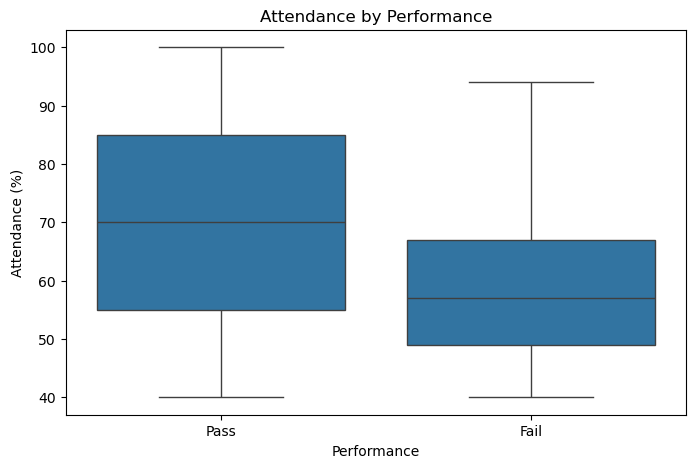

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="performance",
    y="attendance"
)

plt.title("Attendance by Performance")
plt.xlabel("Performance")
plt.ylabel("Attendance (%)")

plt.show()

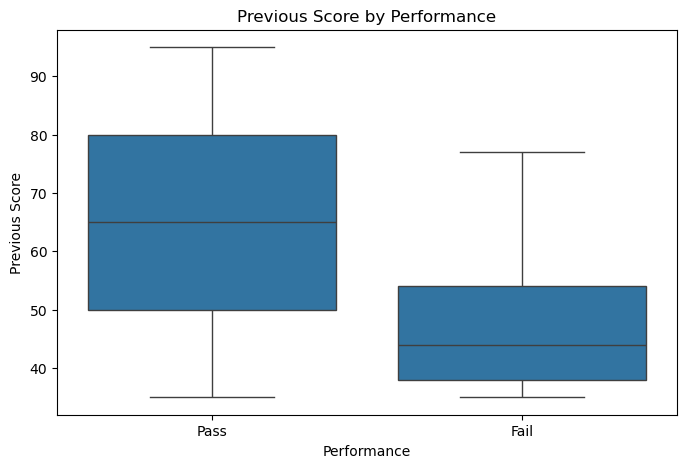

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="performance",
    y="previous_score"
)

plt.title("Previous Score by Performance")
plt.xlabel("Performance")
plt.ylabel("Previous Score")

plt.show()

In [32]:
features = [
    "study_hours",
    "attendance",
    "sleep_hours",
    "internet_usage",
    "assignments_completed",
    "previous_score"
]

X = df[features]

y = df["performance"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']

Target:
performance


In [33]:
X.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score
0,7,56,8,7,10,62
1,4,69,5,3,8,56
2,11,60,7,6,10,45
3,8,99,9,8,4,55
4,5,52,8,6,8,40


In [34]:
y.head()

0    Pass
1    Pass
2    Pass
3    Pass
4    Pass
Name: performance, dtype: object

In [35]:
y = y.map({
    "Fail": 0,
    "Pass": 1
})

print(y.value_counts())

performance
1    9955
0      45
Name: count, dtype: int64


In [36]:
print(X.dtypes)

study_hours              int64
attendance               int64
sleep_hours              int64
internet_usage           int64
assignments_completed    int64
previous_score           int64
dtype: object


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [38]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
performance
1    7964
0      36
Name: count, dtype: int64

Testing target distribution:
performance
1    1991
0       9
Name: count, dtype: int64


In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [40]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [41]:
logistic_predictions = logistic_model.predict(X_test_scaled)

print(logistic_predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [42]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.996
Precision: 0.9959979989994997
Recall   : 1.0
F1 Score : 0.9979949874686717


In [43]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fail       1.00      0.11      0.20         9
        Pass       1.00      1.00      1.00      1991

    accuracy                           1.00      2000
   macro avg       1.00      0.56      0.60      2000
weighted avg       1.00      1.00      0.99      2000



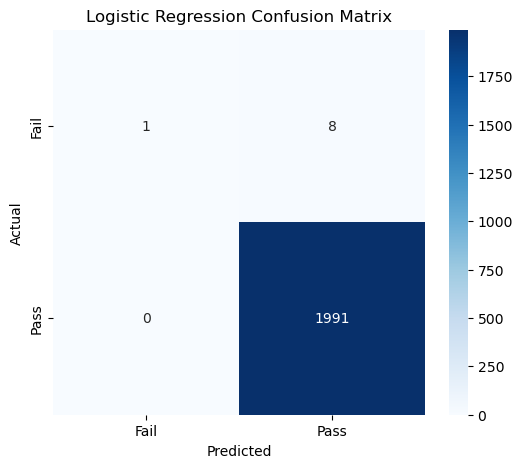

In [44]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [46]:
decision_tree_predictions = decision_tree_model.predict(X_test)

print(decision_tree_predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [47]:
dt_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

dt_precision = precision_score(
    y_test,
    decision_tree_predictions,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    decision_tree_predictions,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    decision_tree_predictions,
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.9945
Precision: 0.9954954954954955
Recall   : 0.9989954796584631
F1 Score : 0.9972424166457758


In [48]:
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         9
        Pass       1.00      1.00      1.00      1991

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000



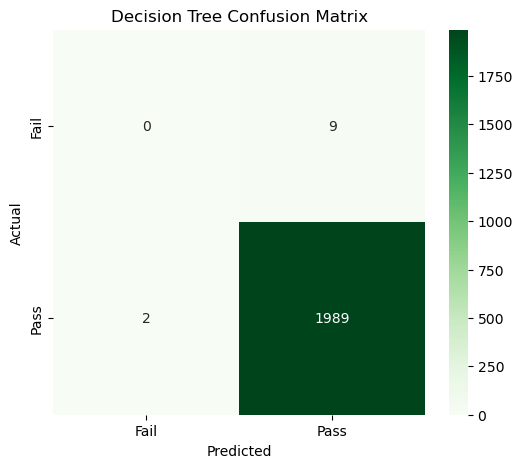

In [49]:
cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(
    X_train_scaled,
    y_train
)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [51]:
naive_bayes_predictions = naive_bayes_model.predict(
    X_test_scaled
)

print(naive_bayes_predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [52]:
nb_accuracy = accuracy_score(
    y_test,
    naive_bayes_predictions
)

nb_precision = precision_score(
    y_test,
    naive_bayes_predictions,
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    naive_bayes_predictions,
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    naive_bayes_predictions,
    zero_division=0
)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes Results
-------------------
Accuracy : 0.996
Precision: 0.9959979989994997
Recall   : 1.0
F1 Score : 0.9979949874686717


In [53]:
print(
    classification_report(
        y_test,
        naive_bayes_predictions,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fail       1.00      0.11      0.20         9
        Pass       1.00      1.00      1.00      1991

    accuracy                           1.00      2000
   macro avg       1.00      0.56      0.60      2000
weighted avg       1.00      1.00      0.99      2000



In [54]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully!")

SVM model trained successfully!


In [55]:
svm_predictions = svm_model.predict(
    X_test_scaled
)

print(svm_predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [56]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    zero_division=0
)

print("SVM Results")
print("-----------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

SVM Results
-----------
Accuracy : 0.9955
Precision: 0.9955
Recall   : 1.0
F1 Score : 0.9977449260836883


In [57]:
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         9
        Pass       1.00      1.00      1.00      1991

    accuracy                           1.00      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      1.00      0.99      2000



In [58]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        dt_accuracy,
        nb_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        dt_precision,
        nb_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        dt_recall,
        nb_recall,
        svm_recall
    ],
    "F1 Score": [
        logistic_f1,
        dt_f1,
        nb_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9960,0.995998,1.000000,0.997995
1,Decision Tree,0.9945,0.995495,0.998995,0.997242
2,Naive Bayes,0.9960,0.995998,1.000000,0.997995
3,SVM,0.9955,0.995500,1.000000,0.997745


In [59]:
results_sorted = results.sort_values(
    by="F1 Score",
    ascending=False
)

results_sorted

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9960,0.995998,1.000000,0.997995
2,Naive Bayes,0.9960,0.995998,1.000000,0.997995
3,SVM,0.9955,0.995500,1.000000,0.997745
1,Decision Tree,0.9945,0.995495,0.998995,0.997242


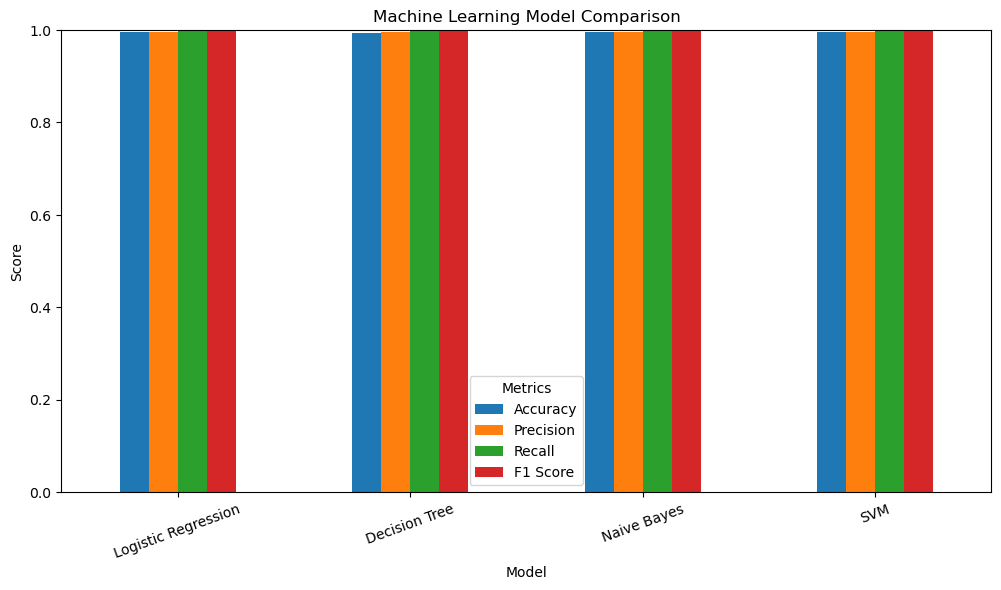

In [60]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.legend(title="Metrics")

plt.show()

In [61]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model based on F1 Score:", best_model_name)

Best Model based on F1 Score: Logistic Regression


In [62]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": decision_tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,previous_score,0.420015
4,assignments_completed,0.257287
1,attendance,0.132228
2,sleep_hours,0.103924
0,study_hours,0.056917
3,internet_usage,0.029629


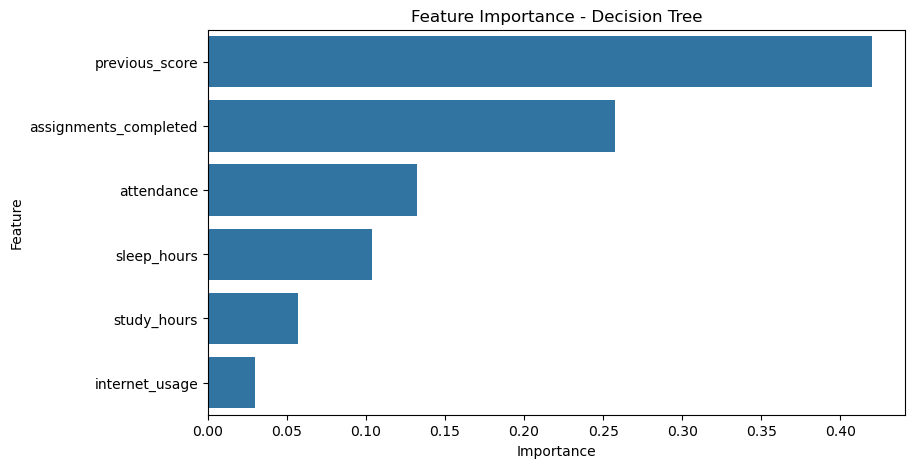

In [63]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [64]:
new_student = pd.DataFrame({
    "study_hours": [6],
    "attendance": [85],
    "sleep_hours": [7],
    "internet_usage": [3],
    "assignments_completed": [8],
    "previous_score": [72]
})

new_student

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score
0,6,85,7,3,8,72


In [65]:
new_student_scaled = scaler.transform(new_student)

prediction = logistic_model.predict(
    new_student_scaled
)

if prediction[0] == 1:
    print("Predicted Performance: PASS")
else:
    print("Predicted Performance: FAIL")

Predicted Performance: PASS


In [66]:
prediction_probability = logistic_model.predict_proba(
    new_student_scaled
)

print("Probability of Fail:", prediction_probability[0][0])
print("Probability of Pass:", prediction_probability[0][1])

Probability of Fail: 1.5096889833254856e-05
Probability of Pass: 0.9999849031101667


In [67]:
def predict_student_performance(
    study_hours,
    attendance,
    sleep_hours,
    internet_usage,
    assignments_completed,
    previous_score
):
    
    student = pd.DataFrame({
        "study_hours": [study_hours],
        "attendance": [attendance],
        "sleep_hours": [sleep_hours],
        "internet_usage": [internet_usage],
        "assignments_completed": [assignments_completed],
        "previous_score": [previous_score]
    })
    
    student_scaled = scaler.transform(student)
    
    prediction = logistic_model.predict(student_scaled)[0]
    
    probability = logistic_model.predict_proba(
        student_scaled
    )[0]
    
    if prediction == 1:
        result = "Pass"
    else:
        result = "Fail"
    
    return result, probability

In [68]:
result, probability = predict_student_performance(
    study_hours=6,
    attendance=85,
    sleep_hours=7,
    internet_usage=3,
    assignments_completed=8,
    previous_score=72
)

print("Predicted Performance:", result)
print("Fail Probability:", round(probability[0] * 100, 2), "%")
print("Pass Probability:", round(probability[1] * 100, 2), "%")

Predicted Performance: Pass
Fail Probability: 0.0 %
Pass Probability: 100.0 %


In [69]:
all_students_X = df[features]

all_students_scaled = scaler.transform(
    all_students_X
)

all_predictions = logistic_model.predict(
    all_students_scaled
)

df["predicted_performance"] = np.where(
    all_predictions == 1,
    "Pass",
    "Fail"
)

df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status,performance,predicted_performance
0,7,56,8,7,10,62,100.00,Placed,Pass,Pass
1,4,69,5,3,8,56,100.00,Placed,Pass,Pass
2,11,60,7,6,10,45,100.00,Placed,Pass,Pass
3,8,99,9,8,4,55,90.17,Placed,Pass,Pass
4,5,52,8,6,8,40,78.82,Placed,Pass,Pass


In [70]:
at_risk_students = df[
    df["predicted_performance"] == "Fail"
]

print(
    "Number of students predicted to be at risk:",
    len(at_risk_students)
)

Number of students predicted to be at risk: 7


In [71]:
at_risk_students[
    [
        "study_hours",
        "attendance",
        "sleep_hours",
        "internet_usage",
        "assignments_completed",
        "previous_score",
        "exam_score",
        "predicted_performance"
    ]
].head(20)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,predicted_performance
186,1,47,5,10,0,46,26.89,Fail
4483,1,56,6,8,0,37,36.08,Fail
6198,1,54,4,9,1,47,33.49,Fail
7362,2,45,4,10,0,47,48.28,Fail
8570,2,57,4,10,0,38,31.83,Fail
9319,1,46,4,2,0,41,31.97,Fail
9721,1,45,6,7,0,37,50.76,Fail


In [72]:
at_risk_percentage = (
    len(at_risk_students) / len(df)
) * 100

print(
    "Percentage of students predicted to be at risk:",
    round(at_risk_percentage, 2),
    "%"
)

Percentage of students predicted to be at risk: 0.07 %


In [74]:
at_risk_students.to_csv(
    "at_risk_students.csv",
    index=False
)

print("At-risk student file saved successfully!")

At-risk student file saved successfully!


In [75]:
comparison = pd.DataFrame({
    "Actual": df["performance"],
    "Predicted": df["predicted_performance"]
})

comparison.head(20)

,Actual,Predicted
0,Pass,Pass
1,Pass,Pass
2,Pass,Pass
3,Pass,Pass
4,Pass,Pass
5,Pass,Pass
6,Pass,Pass
7,Pass,Pass
8,Pass,Pass
9,Pass,Pass


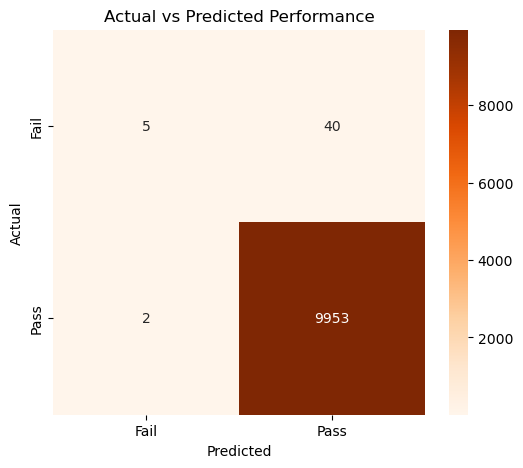

In [76]:
actual_performance = df["performance"].map({
    "Fail": 0,
    "Pass": 1
})

predicted_performance = df["predicted_performance"].map({
    "Fail": 0,
    "Pass": 1
})

cm = confusion_matrix(
    actual_performance,
    predicted_performance
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Actual vs Predicted Performance")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [78]:
df.to_csv(
    "student_performance_predictions.csv",
    index=False
)

print("Final prediction dataset saved successfully!")

Final prediction dataset saved successfully!


In [81]:
import joblib

joblib.dump(
    logistic_model,
    "student_performance_model.pkl"
)

joblib.dump(
    scaler,
    "student_performance_scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [82]:
loaded_model = joblib.load(
    "student_performance_model.pkl"
)

loaded_scaler = joblib.load(
    "student_performance_scaler.pkl"
)

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


In [83]:
test_student = pd.DataFrame({
    "study_hours": [8],
    "attendance": [90],
    "sleep_hours": [7],
    "internet_usage": [2],
    "assignments_completed": [9],
    "previous_score": [80]
})

test_student_scaled = loaded_scaler.transform(
    test_student
)

prediction = loaded_model.predict(
    test_student_scaled
)[0]

if prediction == 1:
    print("Predicted Performance: PASS")
else:
    print("Predicted Performance: FAIL")

Predicted Performance: PASS
